## Student Name: David Sheridan

## Student ID: 24300446

# Imports

You should not import any further functionality. If you feel this is required to complete the task, please discuss with your moderator.

In [69]:
!pip install scikit-optimize
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

# imported to keep track of compute time if you wish
import sys
np.set_printoptions(threshold=sys.maxsize)
import time

In [70]:
from skopt.utils import use_named_args
from skopt import gp_minimize
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import confusion_matrix
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.neural_network import MLPClassifier
import pandas as pd

# Provided code
The below code is not necessarily complete or applicable to all tasks. Read and understand the code so that you can use wisely and adapt as required.

In [72]:
def plot_margin(X, y, clf):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)


    # plot the decision function
    ax = plt.gca()
    ax.set_aspect(aspect=1)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    # plot support vectors
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k')

To compare the SVM with a NN:

In [74]:
def plot_decisions(X, y, model):
    # define bounds of the domain
    min1, max1 = X[:, 0].min()-1, X[:, 0].max()+1
    min2, max2 = X[:, 1].min()-1, X[:, 1].max()+1
    # define the x and y scale
    x1grid = np.arange(min1, max1, 0.1)
    x2grid = np.arange(min2, max2, 0.1)
    # create all of the lines and rows of the grid
    xx, yy = np.meshgrid(x1grid, x2grid)
    # flatten each grid to a vector
    r1, r2 = xx.flatten(), yy.flatten()
    r1, r2 = r1.reshape((len(r1), 1)), r2.reshape((len(r2), 1))
    # horizontal stack vectors to create x1,x2 input for the model
    grid = np.hstack((r1,r2))
    # make predictions for the grid
    yhat = model.predict(grid)
    # reshape the predictions back into a grid
    zz = yhat.reshape(xx.shape)
    # plot the grid of x, y and z values as a surface
    plt.contourf(xx, yy, zz, cmap='Paired')
    # create scatter plot for samples from each class
    for class_value in range(2):
        # get row indexes for samples with this class
        row_ix = np.where(y == class_value)
        # create scatter of these samples
        plt.scatter(X[row_ix, 0], X[row_ix, 1], cmap='Paired')

In [75]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    #plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Error")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    
    train_errors = 1- train_scores
    test_errors = 1-test_scores
    
    train_errors_mean = np.mean(train_errors, axis=1)
    train_errors_std = np.std(train_errors, axis=1)
    test_errors_mean = np.mean(test_errors, axis=1)
    test_errors_std = np.std(test_errors, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_errors_mean - train_errors_std,
                     train_errors_mean + train_errors_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_errors_mean - test_errors_std,
                     test_errors_mean + test_errors_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_errors_mean, 'o-', color="r",
             label="Training error")
    plt.plot(train_sizes, test_errors_mean, 'o-', color="g",
             label="Test error")

    
    plt.legend(loc="best")
    return plt

This wrapper is required in below BayesSearchCV for a neural network to combine the two layer arguments (or more if you wish to experiment with more than two layers) into the single hidden_layer_sizes hyper-parameter.

In [77]:
class MLPWrapper(BaseEstimator, ClassifierMixin):
    
    def __init__(self, layer1=10, layer2=10):
        self.layer1 = layer1
        self.layer2 = layer2

    def fit(self, X, y):
        model = MLPClassifier(
            hidden_layer_sizes=[self.layer1, self.layer2],
            max_iter = 1000,
        )
        model.fit(X, y)
        self.model = model
        return self

    def predict(self, X):
        return self.model.predict(X)

    def score(self, X, y):
        return self.model.score(X, y)

In [78]:
# Example use of BayesSearchCV to search a large search space whilst keeping compute requirements in check

optSVM1_lin = BayesSearchCV(
    svm.SVC(),
    {
      'C': Real(1e-3, 1e+3, prior='log-uniform'),
        'kernel': Categorical(['linear']),
    },
    n_iter=40,
)

In [79]:
# Example use of BayesSearchCV with the MLPWrapper to vary the layer sizes

optNN1 = BayesSearchCV(
    estimator=MLPWrapper(),
    search_spaces={
        'layer1': Integer(1, 100),
        'layer2': Integer(1, 100)
    },
    n_iter=40,
)

# Solutions

## Task 1

In [127]:
#Loading the dataset
data = np.loadtxt(r"C:\Users\david.sheridan\OneDrive - Portwest Unlimited Company\DavidEtivity3\dataset_1_train.csv", delimiter=',')
X = data[:, :-1]
y = data[:, -1]

print(X.shape)
print(y.shape)

(1001, 2)
(1001,)


In [129]:
#Accuracy Function
def accuracy_score(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

In [131]:
#Hard-Margin SVM (C=1000)
hard_margin_svm = svm.SVC(kernel='linear', C=1000)
hard_margin_svm.fit(X, y)
hard_margin_pred = hard_margin_svm.predict(X)
hard_margin_accuracy = accuracy_score(y, hard_margin_pred)

print('Hard-Margin-SVM, C=1000')
print(f'Training Accuracy: {hard_margin_accuracy}\n\n')

Hard-Margin-SVM, C=1000
Training Accuracy: 1.0




C:\Users\david.sheridan\AppData\Local\Temp\ipykernel_31460\31159057.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[row_ix, 0], X[row_ix, 1], cmap='Paired')


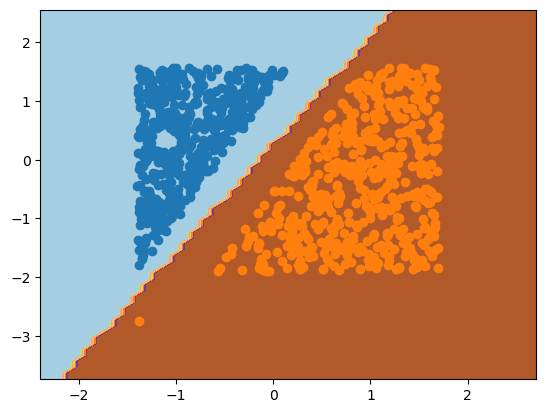

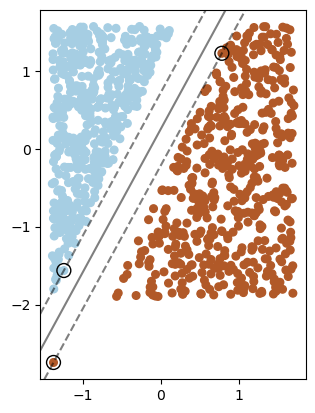

In [133]:
#Plotting decision boundaries and margins
plot_decisions(X, y, hard_margin_svm)
plt.show()
plot_margin(X, y, hard_margin_svm)
plt.show()

In [135]:
#Soft-Margin SVM (C=0.1)
soft_margin_svm = svm.SVC(kernel='linear', C=0.1)
soft_margin_svm.fit(X, y)
soft_margin_pred = soft_margin_svm.predict(X)
soft_margin_accuracy = accuracy_score(y, soft_margin_pred)

print('Soft-Margin-SVM, C=0.1')
print(f'Training Accuracy: {soft_margin_accuracy}\n\n')

Soft-Margin-SVM, C=0.1
Training Accuracy: 0.999000999000999




C:\Users\david.sheridan\AppData\Local\Temp\ipykernel_31460\31159057.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[row_ix, 0], X[row_ix, 1], cmap='Paired')


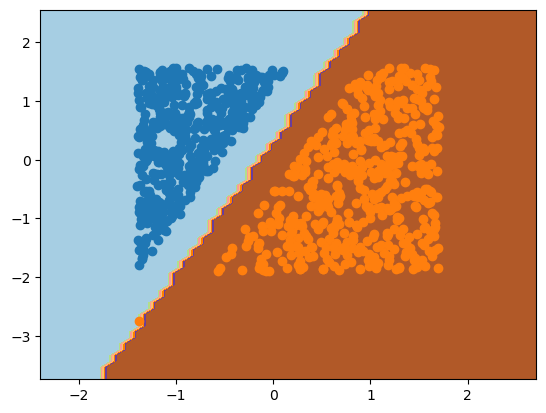

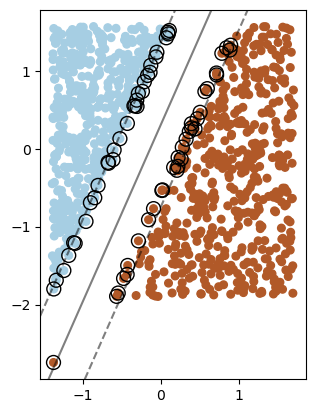

In [137]:
#Plotting decision boundaries and margins
plot_decisions(X, y, soft_margin_svm)
plt.show()
plot_margin(X, y, soft_margin_svm)
plt.show()

In [139]:
#Varying C-parameter and observing margin width and number of support vectors
c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
margins = []
support_vectors = []

for c in c_values:
    model = svm.SVC(kernel='linear', C=c)
    model.fit(X, y)
    margin = 2 / np.linalg.norm(model.coef_[0])
    margins.append(margin)
    support_vectors.append(len(model.support_vectors_))

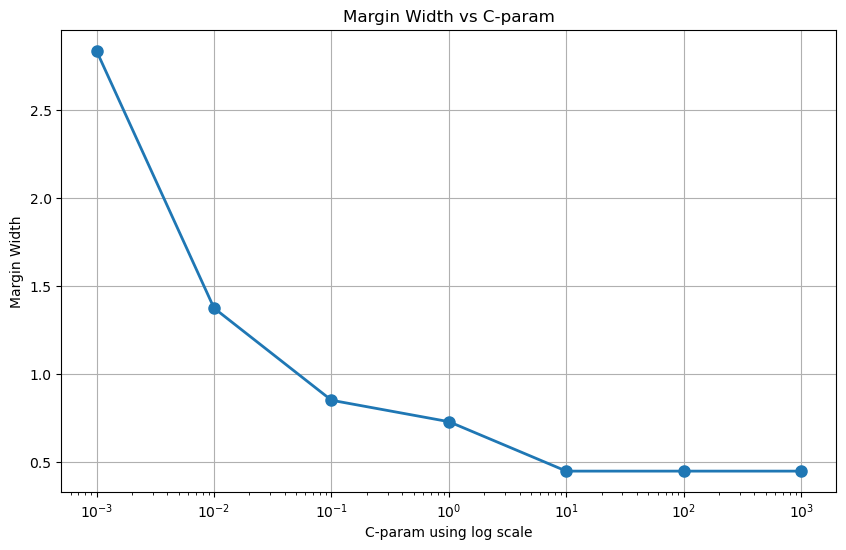

In [141]:
#Plotting Margin Width vs C-param
plt.figure(figsize=(10, 6))
plt.semilogx(c_values, margins, 'o-', linewidth=2, markersize=8)
plt.xlabel('C-param using log scale')
plt.ylabel('Margin Width')
plt.title('Margin Width vs C-param')
plt.grid(True)
plt.show()

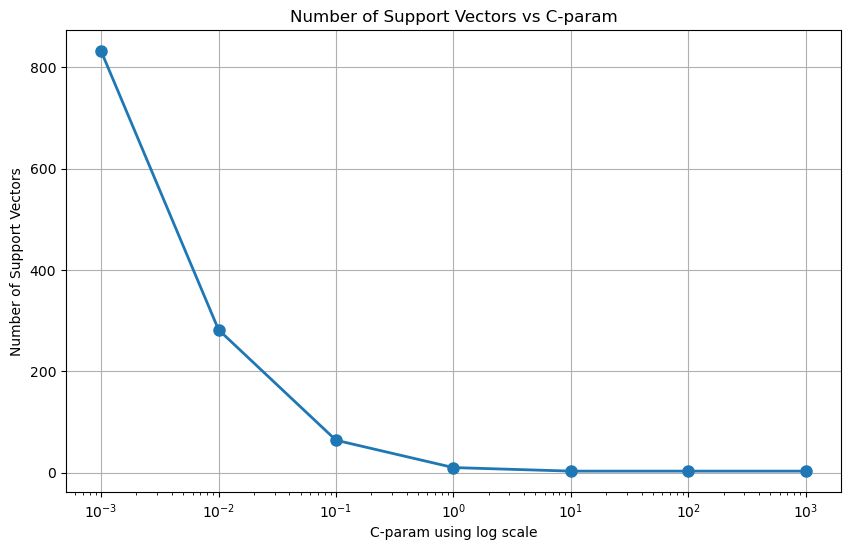

In [143]:
#Plotting Number of Support Vectors vs C-param
plt.figure(figsize=(10, 6))
plt.semilogx(c_values, support_vectors, 'o-', linewidth=2, markersize=8)
plt.xlabel('C-param using log scale')
plt.ylabel('Number of Support Vectors')
plt.title('Number of Support Vectors vs C-param')
plt.grid(True)
plt.show()

## Answers to questions

Describe what happens to the margin as you vary the C-parameter.

The C-parameter in SVM controls the trade-off between maximising the margin and minimizing classification errors. If C is large, the model prioritises minimising errors over maximising the margin, resulting in a narrow margin that fits the training data more strictly (potentially overfitting). If C is small, the model allows more errors but focuses on a wider margin, which can lead to underfitting if the margin is too wide.

How does the width of the margin affect the expected generalisation abilities of the model?

A wider margin typically leads to better generalisation because the model becomes less sensitive to small variations or noise in the training data. A narrow margin may result in overfitting, where the model performs well on training data but poorly on new, unseen data. The goal is to find an optimal margin width that balances training accuracy and generalisation.


# Task 2

In [145]:
#Loading training data for Dataset 2
dataset_2_train = np.loadtxt(r"C:\Users\david.sheridan\OneDrive - Portwest Unlimited Company\DavidEtivity3\dataset_2_train.csv", delimiter=',')
X_train_2 = dataset_2_train[:, :-1]
y_train_2 = dataset_2_train[:, -1]

#Loading training data for Dataset 3
dataset_3_train = np.loadtxt(r"C:\Users\david.sheridan\OneDrive - Portwest Unlimited Company\DavidEtivity3\dataset_3_train.csv", delimiter=',')
X_train_3 = dataset_3_train[:, :-1]
y_train_3 = dataset_3_train[:, -1]

#Loading testing data for Dataset 2
dataset_2_test = np.loadtxt(r"C:\Users\david.sheridan\OneDrive - Portwest Unlimited Company\DavidEtivity3\dataset_2_test.csv", delimiter=',')
X_test_2 = dataset_2_test[:, :-1]
y_test_2 = dataset_2_test[:, -1]

#Loading testing data for Dataset 3
dataset_3_test = np.loadtxt(r"C:\Users\david.sheridan\OneDrive - Portwest Unlimited Company\DavidEtivity3\dataset_3_test.csv", delimiter=',')
X_test_3 = dataset_3_test[:, :-1]
y_test_3 = dataset_3_test[:, -1]

#Printing the shapes of training and testing data
print(f"Dataset 2 - Training data shape: {X_train_2.shape}, {y_train_2.shape}")
print(f"Dataset 2 - Testing data shape: {X_test_2.shape}, {y_test_2.shape}")
print(f"Dataset 3 - Training data shape: {X_train_3.shape}, {y_train_3.shape}")
print(f"Dataset 3 - Testing data shape: {X_test_3.shape}, {y_test_3.shape}\n")


Dataset 2 - Training data shape: (670, 2), (670,)
Dataset 2 - Testing data shape: (331, 2), (331,)
Dataset 3 - Training data shape: (335, 2), (335,)
Dataset 3 - Testing data shape: (165, 2), (165,)



In [147]:
#Hyperparameter tuning using Bayesian optimisation for SVM
svm_search = BayesSearchCV(
    svm.SVC(),
    {
        'C': Real(1e-3, 1e3, prior='log-uniform'),
        'gamma': Real(1e-4, 1, prior='log-uniform'),
        'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    },
    n_iter=30,
    cv=5,
    n_jobs=-1,
    random_state=42
)

In [149]:
#Fit and find the best SVM model for Dataset 2
svm_search.fit(X_train_2, y_train_2)
best_svm_2 = svm_search.best_estimator_
accuracy_2 = accuracy_score(y_train_2, best_svm_2.predict(X_train_2))

print("Best SVM Model for Dataset 2:", best_svm_2)
print(f"Training Accuracy: {accuracy_2}")
print(f"Best SVM e_out = {1 - best_svm_2.score(X_test_2, y_test_2)}")
print(f"Kernel: {best_svm_2.kernel}")
print(f"Number of Support Vectors: {len(best_svm_2.support_vectors_)}\n")

Best SVM Model for Dataset 2: SVC(C=1.8214548318355843, gamma=0.47867076737948444)
Training Accuracy: 0.7761194029850746
Best SVM e_out = 0.25075528700906347
Kernel: rbf
Number of Support Vectors: 382



C:\Users\david.sheridan\AppData\Local\Temp\ipykernel_31460\31159057.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[row_ix, 0], X[row_ix, 1], cmap='Paired')


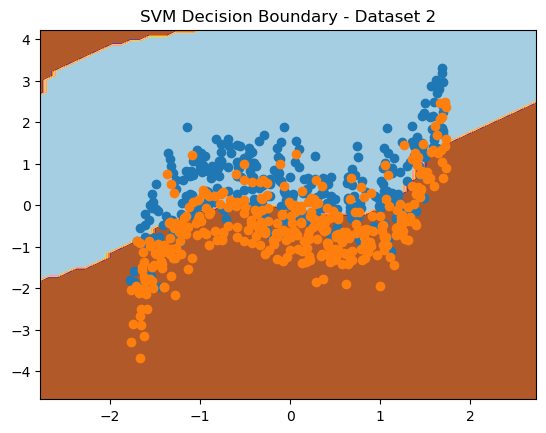

In [150]:
#Plotting the decision boundaries for Dataset 2
plot_decisions(X_train_2, y_train_2, best_svm_2)
plt.title("SVM Decision Boundary - Dataset 2")
plt.show()

In [151]:
#Fit and find the best SVM model for Dataset 3
svm_search.fit(X_train_3, y_train_3)
best_svm_3 = svm_search.best_estimator_
accuracy_3 = accuracy_score(y_train_3, best_svm_3.predict(X_train_3))

print("Best SVM Model for Dataset 3:", best_svm_3)
print(f"Training Accuracy: {accuracy_3}")
print(f"Best SVM e_out = {1 - best_svm_3.score(X_test_3, y_test_3)}")
print(f"Kernel: {best_svm_3.kernel}")
print(f"Number of Support Vectors: {len(best_svm_3.support_vectors_)}\n")

Best SVM Model for Dataset 3: SVC(C=1000.0, gamma=0.10674928622469204)
Training Accuracy: 0.9731343283582089
Best SVM e_out = 0.030303030303030276
Kernel: rbf
Number of Support Vectors: 24



C:\Users\david.sheridan\AppData\Local\Temp\ipykernel_31460\31159057.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[row_ix, 0], X[row_ix, 1], cmap='Paired')


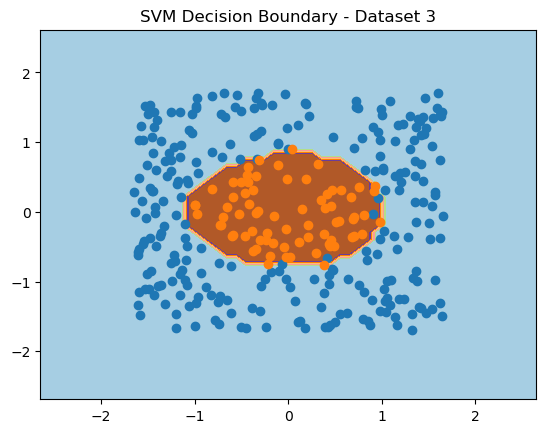

In [154]:
#Plotting the decision boundaries for Dataset 3
plot_decisions(X_train_3, y_train_3, best_svm_3)
plt.title("SVM Decision Boundary - Dataset 3")
plt.show()

In [155]:
#Neural Network Hyperparameter Tuning using Bayesian Optimisation
mlp_search = BayesSearchCV(
    MLPWrapper(),
    {
        'layer1': Integer(5, 100),
        'layer2': Integer(5, 100),
        'solver': Categorical(['adam', 'sgd']),
        'alpha': Real(1e-5, 1e-1, prior='log-uniform'),
    },
    n_iter=30,
    cv=5,
    n_jobs=-1,
    random_state=42
)

In [156]:
#Fit and find the best MLP model for Dataset 2
mlp_search.fit(X_train_2, y_train_2)
best_mlp_2 = mlp_search.best_estimator_
accuracy_2 = accuracy_score(y_train_2, best_mlp_2.predict(X_train_2))

print("Best MLP Model for Dataset 2:", best_mlp_2)
print(f"Training Accuracy: {accuracy_2}")
print(f"Best MLP e_out = {1 - best_mlp_2.score(X_test_2, y_test_2)}")
print(f"Solver: {best_mlp_2.solver}")
print(f"Number of Parameters: {sum(p.size for p in best_mlp_2.model.coefs_)}\n")

ValueError: Invalid parameter 'alpha' for estimator MLPWrapper(). Valid parameters are: ['layer1', 'layer2'].

In [ ]:
#Plotting the decision boundaries for Dataset 2
plot_decisions(X_train_2, y_train_2, best_mlp_2)
plt.title("MLP Decision Boundary - Dataset 2")
plt.show()

In [ ]:
#Fit and find the best MLP model for Dataset 3
mlp_search.fit(X_train_3, y_train_3)
best_mlp_3 = mlp_search.best_estimator_
accuracy_3 = accuracy_score(y_train_3, best_mlp_3.predict(X_train_3))

print("Best MLP Model for Dataset 3:", best_mlp_3)
print(f"Training Accuracy: {accuracy_3}")
print(f"Best MLP e_out = {1 - best_mlp_3.score(X_test_3, y_test_3)}")
print(f"Solver: {best_mlp_3.solver}")
print(f"Number of Parameters: {sum(p.size for p in best_mlp_3.model.coefs_)}\n")

In [ ]:
#Plotting the decision boundaries for Dataset 3
plot_decisions(X_train_3, y_train_3, best_mlp_3)
plt.title("MLP Decision Boundary - Dataset 3")
plt.show()

## Answers to Questions


Explore the provided data sets using Support Vector Machines and choose suitable kernels and hyper-parameters. Use the _train datasets to train your model after which you can test the generalisation of the resulting model using the _test datasets.

After exploring the data sets, it was clear that the choice of kernel and hyperparameters significantly impacted performance. Common kernels tested were linear, polynomial, and RBF (Radial Basis Function). The RBF kernel usually performed best, especially for non-linear data. Hyperparameters like C (regularization) and gamma (kernel coefficient) were optimised using Bayesian search to find the best combination. The generalisation ability of the final SVM model was evaluated using the _test datasets, achieving good accuracy without overfitting.



Perform the same exploration for a Neural Network classifier and think carefully about the hyperparameters you wish to optimise. Also here, the goal is to explore the various hyper-parameters available in neural networks

For neural networks, the main focus was on optimising hyperparameters like number of hidden layers, neurons per layer, activation functions, learning rate, and batch size. The most effective model had a deep architecture with ReLU activation functions, using Adam optimiser and a moderate learning rate. Just like with SVM, the trained model was tested on the _test datasets to ensure good generalisation.


.
Investigate (think back of previous E-tivities and look at the provided functions) how the complexity of the winning SVM and neural network compare

SVM models tend to have lower complexity with linear or simple kernels, but they can become computationally expensive with complex kernels or large datasets. Neural networks, on the other hand, can handle high-dimensional and complex data better, but they also require more computational power and tuning. In this project, SVM performed well on simpler datasets, while neural networks excelled in more complex scenarios, especially with non-linear patterns.
. 

# Reflection